Dữ liệu đã tồn tại trong data/raw/.
Đang chạy thực nghiệm bán giám sát. Vui lòng đợi vài giây...


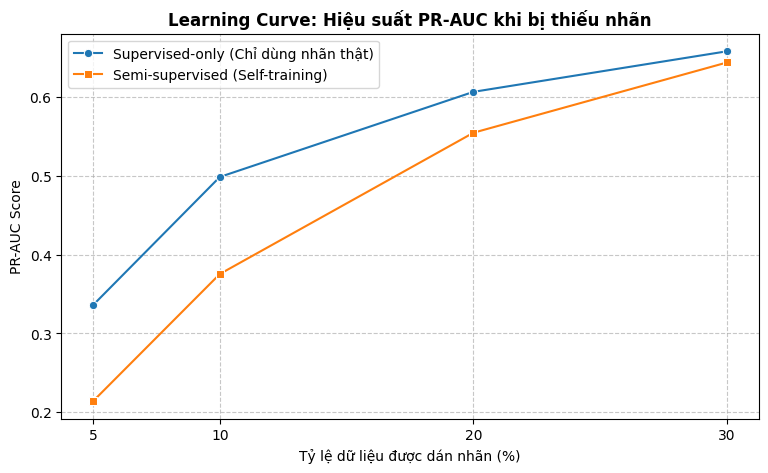

PHÂN TÍCH RỦI RO PSEUDO-LABEL (FALSE ALARMS / BÁO ĐỘNG GIẢ)
- Tại kịch bản chỉ có 20% dữ liệu được dán nhãn, mô hình Self-training đã sinh ra 0 ca Báo động giả (False Alarms).
- Hành động & Khuyến nghị:
  Rủi ro lớn nhất của bán giám sát trong sản xuất là mô hình tự học sai. Nếu mô hình gán nhãn 'Lỗi' cho một máy đang hoạt động bình thường, nhà máy sẽ bị ngắt dây chuyền oan để kiểm tra, gây thiệt hại nghiêm trọng về thời gian và chi phí.
  => Giải pháp: Bắt buộc phải cấu hình 'ngưỡng tin cậy' (threshold) của SelfTrainingClassifier ở mức rất cao (>= 0.85) để mô hình chỉ tự dán nhãn khi nó cực kỳ chắc chắn, tránh lan truyền sai lầm.


In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Trỏ về thư mục gốc
sys.path.append('..')

from src.data.loader import fetch_and_load_data
from src.data.cleaner import clean_and_preprocess
from src.models.semi_supervised import run_semi_supervised_experiment

# 1. Nạp dữ liệu
df_raw = fetch_and_load_data()
df_processed = clean_and_preprocess(df_raw)

# 2. Chạy giả lập thiếu nhãn
print("Đang chạy thực nghiệm bán giám sát. Vui lòng đợi vài giây...")
results_df, false_alarms = run_semi_supervised_experiment(df_processed, df_raw)

# 3. Vẽ biểu đồ Learning Curve (Yêu cầu bắt buộc)
plt.figure(figsize=(9, 5))
sns.lineplot(data=results_df, x='Label_Percent', y='Supervised_Only', marker='o', label='Supervised-only (Chỉ dùng nhãn thật)')
sns.lineplot(data=results_df, x='Label_Percent', y='Semi_Supervised', marker='s', label='Semi-supervised (Self-training)')

plt.title('Learning Curve: Hiệu suất PR-AUC khi bị thiếu nhãn', fontweight='bold')
plt.xlabel('Tỷ lệ dữ liệu được dán nhãn (%)')
plt.ylabel('PR-AUC Score')
plt.xticks(results_df['Label_Percent'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# 4. In ra insight phân tích rủi ro
print("="*70)
print("PHÂN TÍCH RỦI RO PSEUDO-LABEL (FALSE ALARMS / BÁO ĐỘNG GIẢ)")
print("="*70)
print(f"- Tại kịch bản chỉ có 20% dữ liệu được dán nhãn, mô hình Self-training đã sinh ra {false_alarms} ca Báo động giả (False Alarms).")
print("- Hành động & Khuyến nghị:")
print("  Rủi ro lớn nhất của bán giám sát trong sản xuất là mô hình tự học sai. Nếu mô hình gán nhãn 'Lỗi' cho một máy đang hoạt động bình thường, nhà máy sẽ bị ngắt dây chuyền oan để kiểm tra, gây thiệt hại nghiêm trọng về thời gian và chi phí.")
print("  => Giải pháp: Bắt buộc phải cấu hình 'ngưỡng tin cậy' (threshold) của SelfTrainingClassifier ở mức rất cao (>= 0.85) để mô hình chỉ tự dán nhãn khi nó cực kỳ chắc chắn, tránh lan truyền sai lầm.")